# Analyse des avis et alertes ANSSI
Chargement du CSV consolide puis exploration visualisations et machine learning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1 Chargement et exploration

In [2]:
df = pd.read_csv("donnees_consolidees.csv")
print(df.shape)
df.head()

(79463, 14)


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Lien,Score CVSS,Base Severity,CWE,Description,Editeur,Produit,Versions,Score EPSS
0,CERTFR-2024-AVI-0001,Vulnérabilité dans StormShield Network Security,Avis,2024-01-02,CVE-2023-48795,https://www.cert.ssi.gouv.fr/avis/CERTFR-2024-...,Non disponible,Non disponible,Non disponible,The SSH transport protocol with certain OpenSS...,NaN,NaN,NaN,0.529980000
1,CERTFR-2024-AVI-0002,Multiples vulnérabilités dans Moxa OnCell G315...,Avis,2024-01-02,CVE-2023-6093,https://www.cert.ssi.gouv.fr/avis/CERTFR-2024-...,5.3,MEDIUM,CWE-1021,A clickjacking vulnerability has been identifi...,Moxa,OnCell G3150A-LTE Series,1.0,0.000690000
2,CERTFR-2024-AVI-0002,Multiples vulnérabilités dans Moxa OnCell G315...,Avis,2024-01-02,CVE-2013-2566,https://www.cert.ssi.gouv.fr/avis/CERTFR-2024-...,Non disponible,Non disponible,Non disponible,"The RC4 algorithm, as used in the TLS protocol...",NaN,NaN,NaN,0.903240000
3,CERTFR-2024-AVI-0002,Multiples vulnérabilités dans Moxa OnCell G315...,Avis,2024-01-02,CVE-2004-2761,https://www.cert.ssi.gouv.fr/avis/CERTFR-2024-...,Non disponible,Non disponible,Non disponible,The MD5 Message-Digest Algorithm is not collis...,NaN,NaN,NaN,0.084550000
4,CERTFR-2024-AVI-0002,Multiples vulnérabilités dans Moxa OnCell G315...,Avis,2024-01-02,CVE-2016-2183,https://www.cert.ssi.gouv.fr/avis/CERTFR-2024-...,Non disponible,Non disponible,Non disponible,"The DES and Triple DES ciphers, as used in the...",NaN,NaN,NaN,0.400160000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79463 entries, 0 to 79462
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID ANSSI       79463 non-null  str  
 1   Titre ANSSI    79463 non-null  str  
 2   Type           79463 non-null  str  
 3   Date           79463 non-null  str  
 4   CVE            79463 non-null  str  
 5   Lien           79463 non-null  str  
 6   Score CVSS     79463 non-null  str  
 7   Base Severity  79463 non-null  str  
 8   CWE            79463 non-null  str  
 9   Description    79463 non-null  str  
 10  Editeur        73853 non-null  str  
 11  Produit        76149 non-null  str  
 12  Versions       74161 non-null  str  
 13  Score EPSS     79463 non-null  str  
dtypes: str(14)
memory usage: 8.5 MB


In [4]:
# repartition des types de bulletins
df["Type"].value_counts()

Type
Avis      79302
Alerte      161
Name: count, dtype: int64

In [5]:
# on convertit les scores en numerique
df["Score CVSS"] = pd.to_numeric(df["Score CVSS"], errors="coerce")
df["Score EPSS"] = pd.to_numeric(df["Score EPSS"], errors="coerce")

# on garde les lignes avec un score cvss pour les analyses
data = df[df["Score CVSS"].notna()].copy()
print(data.shape)

(15214, 14)


In [6]:
data["Base Severity"].value_counts()

Base Severity
MEDIUM      7203
HIGH        6154
LOW         1142
CRITICAL     707
NONE           8
Name: count, dtype: int64

## 2 Visualisations

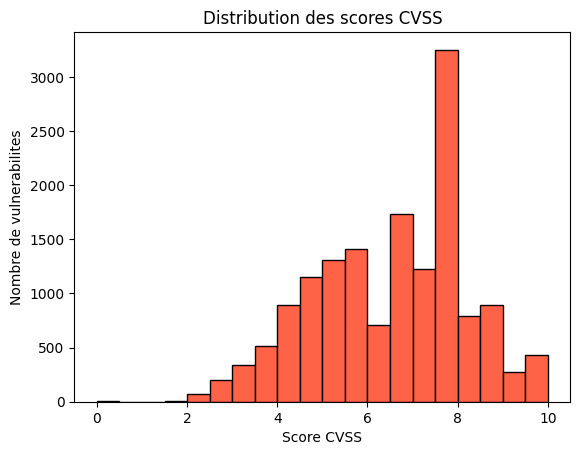

In [7]:
# histogramme des scores cvss
plt.figure()
plt.hist(data["Score CVSS"], bins=20, color="tomato", edgecolor="black")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnerabilites")
plt.show()

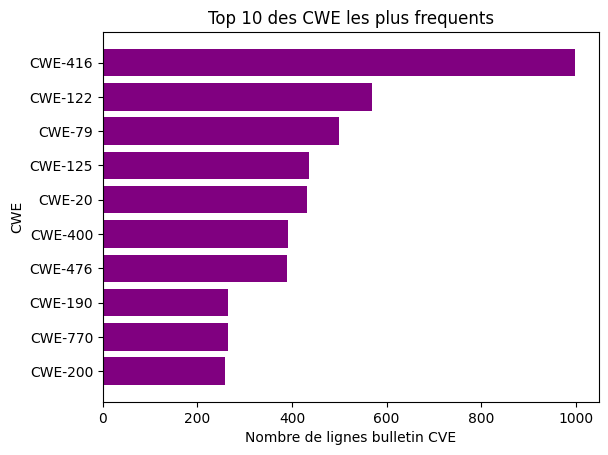

In [8]:
# barplot horizontal des cwe les plus frequents
top_cwe = data[data["CWE"] != "Non disponible"]["CWE"].value_counts().head(10)
plt.figure()
plt.barh(top_cwe.index[::-1], top_cwe.values[::-1], color="purple")
plt.title("Top 10 des CWE les plus frequents")
plt.xlabel("Nombre de lignes bulletin CVE")
plt.ylabel("CWE")
plt.show()

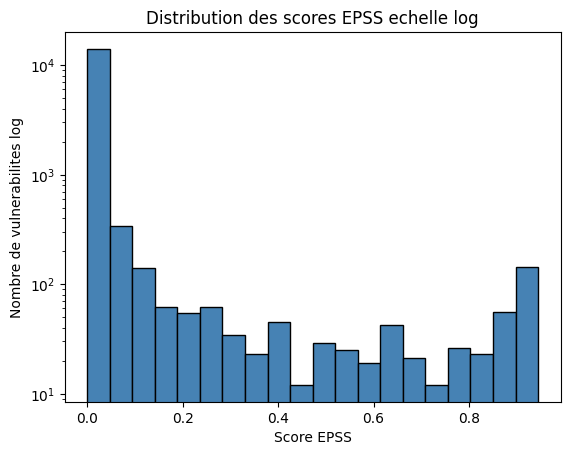

In [9]:
# distribution des scores epss
# les epss manquants sont deja en NaN donc pas comptes comme 0
# echelle log car beaucoup de scores sont proches de 0
plt.figure()
plt.hist(data["Score EPSS"].dropna(), bins=20, color="steelblue", edgecolor="black")
plt.yscale("log")
plt.title("Distribution des scores EPSS echelle log")
plt.xlabel("Score EPSS")
plt.ylabel("Nombre de vulnerabilites log")
plt.show()

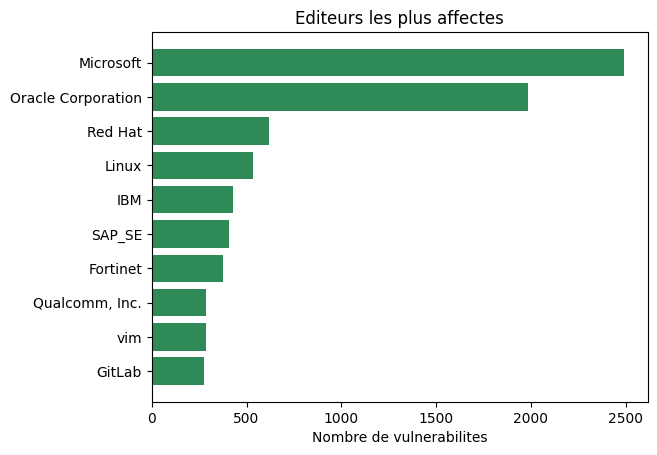

In [10]:
# top 10 des editeurs les plus touches
top_edit = data[data["Editeur"] != "Non disponible"]["Editeur"].value_counts().head(10)
plt.figure()
plt.barh(top_edit.index[::-1], top_edit.values[::-1], color="seagreen")
plt.title("Editeurs les plus affectes")
plt.xlabel("Nombre de vulnerabilites")
plt.show()

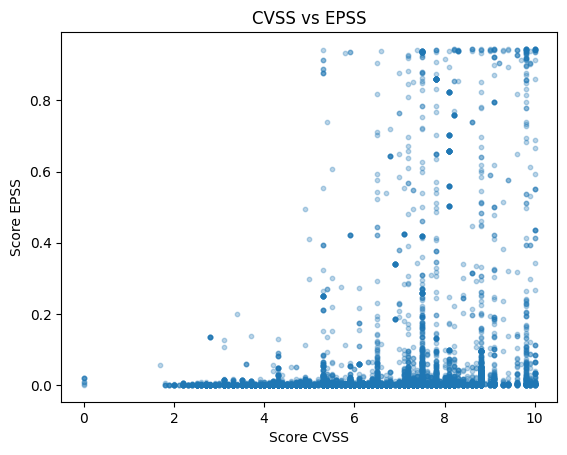

In [11]:
# nuage de points cvss vs epss
plt.figure()
plt.scatter(data["Score CVSS"], data["Score EPSS"], alpha=0.3, s=10)
plt.title("CVSS vs EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

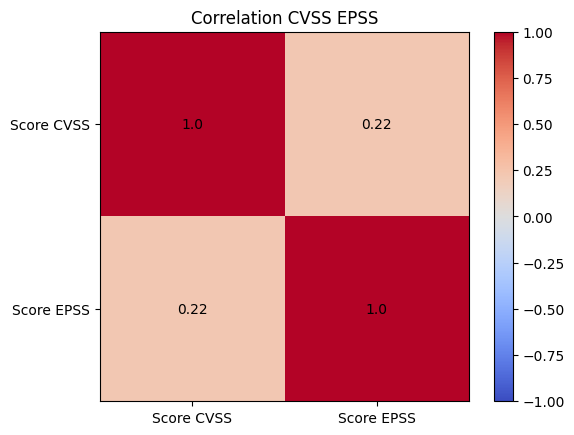

,Score CVSS,Score EPSS
Score CVSS,1.000000,0.224899
Score EPSS,0.224899,1.000000


In [12]:
# heatmap de correlation entre cvss et epss
corr = data[["Score CVSS", "Score EPSS"]].corr()
plt.figure()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks([0, 1], corr.columns)
plt.yticks([0, 1], corr.columns)
# on affiche les valeurs de correlation
for i in range(2):
    for j in range(2):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")
plt.title("Correlation CVSS EPSS")
plt.show()
corr

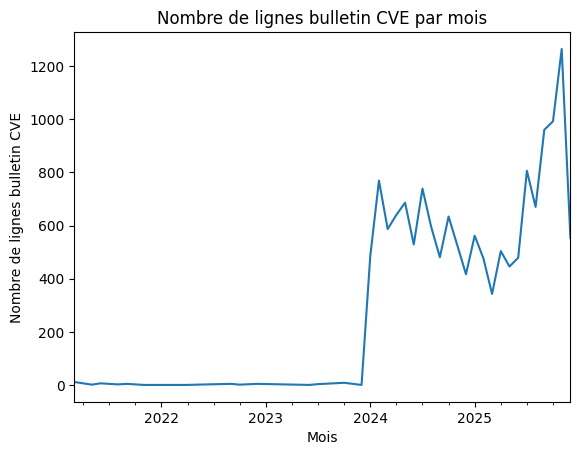

In [13]:
# evolution du nombre de lignes bulletin cve dans le temps
# attention on compte les lignes bulletin cve pas les cve uniques
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
par_mois = data.groupby(data["Date"].dt.to_period("M")).size()
plt.figure()
par_mois.plot()
plt.title("Nombre de lignes bulletin CVE par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de lignes bulletin CVE")
plt.show()

## 3 Machine learning

Predire Base Severity directement depuis le CVSS etait trop artificiel car la gravite est deja calculee a partir du CVSS

Modele supervise on predit plutot si une vulnerabilite a une forte probabilite d exploitation epss eleve EPSS superieur ou egal a 0.5 a partir du CVSS du type de bulletin du CWE et de l annee sans utiliser l EPSS comme variable

Modele non supervise regroupement des vulnerabilites avec KMeans

### Modele supervise

In [14]:
# cible forte probabilite d exploitation
ml = data[data["Score EPSS"].notna()].copy()
ml["epss_eleve"] = (ml["Score EPSS"] >= 0.5).astype(int)

# variables explicatives sans utiliser l epss
ml["type_code"] = (ml["Type"] == "Alerte").astype(int)
ml["cwe_code"] = ml["CWE"].factorize()[0]
ml["annee"] = pd.to_datetime(ml["Date"], errors="coerce").dt.year

X = ml[["Score CVSS", "type_code", "cwe_code", "annee"]]
y = ml["epss_eleve"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy 0.9787280701754386
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4452
           1       0.61      0.29      0.39       108

    accuracy                           0.98      4560
   macro avg       0.80      0.64      0.69      4560
weighted avg       0.97      0.98      0.97      4560



### Modele non supervise

Score silhouette 0.5543998009169961


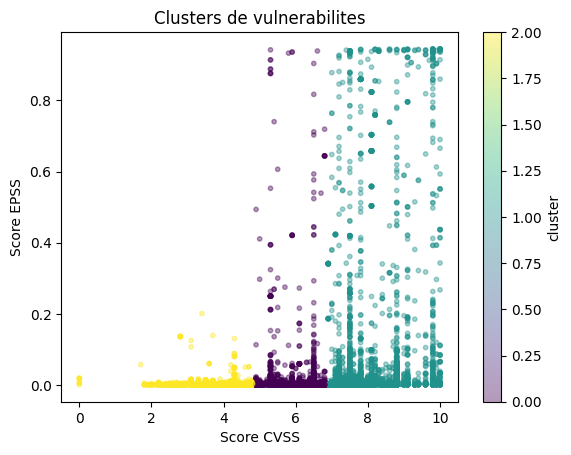

In [15]:
# clustering des vulnerabilites en 3 groupes
clust = ml[["Score CVSS", "Score EPSS"]]
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(clust)

print("Score silhouette", silhouette_score(clust, labels))

plt.figure()
sc = plt.scatter(clust["Score CVSS"], clust["Score EPSS"], c=labels, cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, label="cluster")
plt.title("Clusters de vulnerabilites")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

Interpretation rapide des clusters

Les couleurs correspondent aux numeros de cluster de la colorbar

Les clusters separent les vulnerabilites selon le niveau de CVSS et la probabilite d exploitation EPSS un groupe regroupe les EPSS faibles et les autres les CVSS plus eleves ou les EPSS plus forts

## 4 Conclusion

Predire la gravite depuis le CVSS donnait une accuracy de 1 donc pas interessant

Le nouveau modele supervise predit la forte probabilite d exploitation avec des variables independantes de l EPSS ce qui est plus defendable

Le clustering regroupe les vulnerabilites selon leur gravite et leur probabilite d exploitation